# CATSA Dataset: Inter-Label Physiological Relationship Analysis

분석 목표: Baseline, Nback, Stroop, Logic, Sudoku의 생리신호 유사성을 모든 피험자 데이터로 검증
- 각 태스크의 생리신호 특성 비교
- 태스크 간 상관관계 분석
- Nback/Stroop/Logic/Sudoku 통합 가능성 평가

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import find_peaks, butter, filtfilt
from scipy.stats import f_oneway, kruskal, spearmanr, pearsonr
from scipy.spatial.distance import pdist, squareform, euclidean, cosine
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import json

# Configuration
DATASET_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')
FS_BVP = 64
FS_ACC = 32
FS_SLOW = 4
EDA_TONIC_CUTOFF_HZ = 0.05
EDA_FILTER_ORDER = 2

TASKS = ['Baseline', 'Nback', 'Stroop', 'Logic', 'Sudoku']
TASK_COLORS = {'Baseline': '#2ecc71', 'Nback': '#3498db', 'Stroop': '#e74c3c', 'Logic': '#9b59b6', 'Sudoku': '#f39c12'}

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('✓ Libraries loaded')

✓ Libraries loaded


## Section 1: Load and Organize Dataset by Subject

모든 subject의 각 task별 생리신호 데이터를 체계적으로 로드

In [2]:
def read_csv_array(path: Path) -> np.ndarray:
    """Read CSV file and convert to numpy array"""
    return pd.read_csv(path).values.astype(np.float32)

def bvp_to_hr_hrv_4hz(bvp_64: np.ndarray, fs: int = 64, out_fs: int = 4,
                     min_peak_distance_sec: float = 0.30,
                     hrv_window_sec: int = 10):
    """Extract HR and HRV from BVP signal"""
    sig = np.asarray(bvp_64, dtype=np.float32).reshape(-1)
    min_dist = max(1, int(fs * min_peak_distance_sec))
    peaks, _ = find_peaks(sig, distance=min_dist)

    n4 = len(sig) // (fs // out_fs)
    t4 = np.arange(n4) / float(out_fs)

    if len(peaks) < 3:
        return np.zeros(n4, dtype=np.float32), np.zeros(n4, dtype=np.float32)

    t_peaks = peaks / float(fs)
    ibi = np.diff(t_peaks)
    ibi = np.clip(ibi, 1e-3, None)
    hr = 60.0 / ibi

    t_ibi = t_peaks[1:]
    hr_4 = np.interp(t4, t_ibi, hr).astype(np.float32)
    ibi_series = pd.Series(ibi)
    hrv = ibi_series.rolling(window=max(2, int(hrv_window_sec)), min_periods=1).std().fillna(0).values
    hrv_4 = np.interp(t4, t_ibi, hrv).astype(np.float32)

    return hr_4, hrv_4

def decompose_eda(eda_4hz: np.ndarray, fs: int = 4, cutoff_hz: float = 0.05, order: int = 2):
    """Decompose EDA into tonic and phasic components"""
    x = np.asarray(eda_4hz, dtype=np.float32).reshape(-1)
    if len(x) < (order * 6 + 1):
        tonic = x.copy()
        phasic = np.zeros_like(x)
        return tonic, phasic

    nyq = 0.5 * fs
    norm = max(1e-4, min(cutoff_hz / nyq, 0.99))
    b, a = butter(order, norm, btype='low')
    tonic = filtfilt(b, a, x).astype(np.float32)
    phasic = (x - tonic).astype(np.float32)
    return tonic, phasic

def load_task_modalities(subject_dir: Path, task: str):
    """Load all modalities for a specific task"""
    task_dir = subject_dir / task
    paths = {
        'acc': task_dir / 'ACC.csv',
        'bvp': task_dir / 'BVP.csv',
        'eda': task_dir / 'EDA.csv',
        'temp': task_dir / 'TEMP.csv',
    }
    if not all(p.exists() for p in paths.values()):
        return None

    acc = read_csv_array(paths['acc'])
    bvp = read_csv_array(paths['bvp']).reshape(-1)
    eda = read_csv_array(paths['eda']).reshape(-1)
    temp = read_csv_array(paths['temp']).reshape(-1)

    if acc.ndim == 1:
        acc = acc.reshape(-1, 1)
    if acc.shape[1] < 3:
        acc = np.tile(acc, (1, 3))[:, :3]
    else:
        acc = acc[:, :3]

    hr_4, hrv_4 = bvp_to_hr_hrv_4hz(bvp, fs=FS_BVP, out_fs=FS_SLOW)
    scl_4, scr_4 = decompose_eda(eda, fs=FS_SLOW, cutoff_hz=EDA_TONIC_CUTOFF_HZ, order=EDA_FILTER_ORDER)

    t4_from_acc = len(acc) // (FS_ACC // FS_SLOW)
    t4_from_bvp = len(bvp) // (FS_BVP // FS_SLOW)
    t4 = min(len(scl_4), len(scr_4), len(temp), len(hr_4), len(hrv_4), t4_from_acc, t4_from_bvp)
    
    if t4 < 60 * FS_SLOW:  # At least 60 seconds
        return None

    scl_4 = scl_4[:t4]
    scr_4 = scr_4[:t4]
    temp = temp[:t4]
    hr_4 = hr_4[:t4]
    hrv_4 = hrv_4[:t4]
    acc = acc[: t4 * (FS_ACC // FS_SLOW)]

    slow = np.stack([scl_4, scr_4, temp, hr_4, hrv_4], axis=1).astype(np.float32)

    return {
        'acc': acc.astype(np.float32),      # (T, 3)
        'bvp': bvp.astype(np.float32),      # (T,)
        'eda': eda.astype(np.float32),      # (T,)
        'temp': temp.astype(np.float32),    # (T,)
        'slow': slow,                        # (T, 5) [SCL, SCR, TEMP, HR, HRV]
    }

# List all subjects
subjects = sorted([p.name for p in DATASET_ROOT.glob('Sub*') if p.is_dir()])
print(f'Found {len(subjects)} subjects: {subjects[:5]}... (showing first 5)')

# Load dataset structure
dataset_by_subject = {}
for subject in subjects:
    subject_dir = DATASET_ROOT / subject
    subject_data = {}
    for task in TASKS:
        mods = load_task_modalities(subject_dir, task)
        if mods is not None:
            subject_data[task] = mods
    if len(subject_data) > 0:
        dataset_by_subject[subject] = subject_data

print(f'\n✓ Loaded data from {len(dataset_by_subject)} subjects')
print(f'  Tasks per subject (example {subjects[0]}): {list(dataset_by_subject[subjects[0]].keys())}')

Found 50 subjects: ['Sub1', 'Sub10', 'Sub11', 'Sub12', 'Sub13']... (showing first 5)

✓ Loaded data from 50 subjects
  Tasks per subject (example Sub1): ['Baseline', 'Nback', 'Stroop', 'Logic', 'Sudoku']


## Section 2: Compute Subject-Level Statistics per Task

각 피험자의 각 task별 생리신호 통계량 계산

In [3]:
def compute_signal_statistics(signal: np.ndarray, signal_type: str = 'generic') -> dict:
    """Compute statistical features from a signal with outlier removal"""
    sig = np.asarray(signal).reshape(-1)
    
    # Define expected physiological ranges
    ranges = {
        'hr': (40, 150),           # Heart rate: 40-150 bpm
        'hrv': (0, 500),           # HRV: 0-500 ms
        'eda': (-50, 50),          # EDA: -50 to +50 µS
        'eda_phasic': (-10, 10),   # EDA phasic: -10 to +10 µS
        'eda_tonic': (-50, 50),    # EDA tonic: -50 to +50 µS
        'temp': (25, 45),          # Temperature: 25-45°C
        'acc': (-5, 5),            # ACC: -5 to +5 g
        'acc_mag': (0, 10),        # ACC magnitude: 0-10 g
        'bvp': (0, 300),           # BVP: 0-300 (unit)
    }
    
    # Remove extreme outliers using 1%-99% percentile
    p1, p99 = np.percentile(sig, [1, 99])
    sig_clipped = np.clip(sig, p1, p99)
    
    # Apply signal-specific range clipping
    if signal_type in ranges:
        min_val, max_val = ranges[signal_type]
        sig_clipped = np.clip(sig_clipped, min_val, max_val)
    
    return {
        'mean': float(np.mean(sig_clipped)),
        'std': float(np.std(sig_clipped)),
        'min': float(np.min(sig_clipped)),
        'max': float(np.max(sig_clipped)),
        'median': float(np.median(sig_clipped)),
        'q25': float(np.percentile(sig_clipped, 25)),
        'q75': float(np.percentile(sig_clipped, 75)),
    }

def compute_acc_magnitude(acc: np.ndarray) -> np.ndarray:
    """Compute ACC magnitude from 3-axis acceleration"""
    return np.linalg.norm(acc, axis=1)

# Compute statistics for each subject-task pair
stats_by_subject_task = {}

for subject in sorted(dataset_by_subject.keys()):
    stats_by_subject_task[subject] = {}
    for task in TASKS:
        if task in dataset_by_subject[subject]:
            mods = dataset_by_subject[subject][task]
            stats_by_subject_task[subject][task] = {
                'acc_x': compute_signal_statistics(mods['acc'][:, 0], 'acc'),
                'acc_y': compute_signal_statistics(mods['acc'][:, 1], 'acc'),
                'acc_z': compute_signal_statistics(mods['acc'][:, 2], 'acc'),
                'acc_mag': compute_signal_statistics(compute_acc_magnitude(mods['acc']), 'acc_mag'),
                'bvp': compute_signal_statistics(mods['bvp'], 'bvp'),
                'eda': compute_signal_statistics(mods['eda'], 'eda'),
                'temp': compute_signal_statistics(mods['temp'], 'temp'),
                'eda_tonic': compute_signal_statistics(mods['slow'][:, 0], 'eda_tonic'),
                'eda_phasic': compute_signal_statistics(mods['slow'][:, 1], 'eda_phasic'),
                'hr': compute_signal_statistics(mods['slow'][:, 3], 'hr'),
                'hrv': compute_signal_statistics(mods['slow'][:, 4], 'hrv'),
            }

print(f'✓ Computed statistics for {len(stats_by_subject_task)} subjects')

# Create summary dataframe for inspection
summary_data = []
for subject in sorted(stats_by_subject_task.keys()):
    for task in TASKS:
        if task in stats_by_subject_task[subject]:
            stats = stats_by_subject_task[subject][task]
            summary_data.append({
                'Subject': subject,
                'Task': task,
                'HR_mean': stats['hr']['mean'],
                'HR_std': stats['hr']['std'],
                'HRV_mean': stats['hrv']['mean'],
                'HRV_std': stats['hrv']['std'],
                'EDA_phasic_mean': stats['eda_phasic']['mean'],
                'EDA_phasic_std': stats['eda_phasic']['std'],
                'TEMP_mean': stats['temp']['mean'],
                'ACC_mag_mean': stats['acc_mag']['mean'],
            })

df_summary = pd.DataFrame(summary_data)
print('\n📊 Sample statistics (first 10 rows):')
display(df_summary.head(10))

✓ Computed statistics for 50 subjects

📊 Sample statistics (first 10 rows):


,Subject,Task,HR_mean,HR_std,HRV_mean,HRV_std,EDA_phasic_mean,EDA_phasic_std,TEMP_mean,ACC_mag_mean
0,Sub1,Baseline,106.638192,6.018657,0.028840,0.034704,-0.001427,0.212096,35.546333,10.0
1,Sub1,Nback,102.408147,7.407073,0.036618,0.051175,0.015545,0.340880,35.548666,10.0
2,Sub1,Stroop,105.147914,13.584732,0.079771,0.051634,0.004083,0.421947,35.703320,10.0
3,Sub1,Logic,103.627014,8.421517,0.037441,0.050832,0.003480,0.414504,35.964736,10.0
4,Sub1,Sudoku,104.742226,7.164553,0.030971,0.028270,0.002931,0.331601,36.056833,10.0
5,Sub10,Baseline,84.299391,14.450634,0.101113,0.061604,-0.002905,0.103126,35.483681,10.0
6,Sub10,Nback,91.562272,16.636518,0.101188,0.055575,0.001941,0.101753,35.765334,10.0
7,Sub10,Stroop,92.164019,16.408277,0.106846,0.057480,0.000369,0.076584,35.801611,10.0
8,Sub10,Logic,90.753026,15.812828,0.097915,0.057037,0.000372,0.101463,36.026770,10.0
9,Sub10,Sudoku,91.705866,17.935737,0.120614,0.060990,0.001292,0.104951,35.875202,10.0


## Section 3: Extract Feature Vectors from Raw Signals

각 subject-task 쌍에서 engineered feature 추출

In [4]:
# Feature extraction: Create feature vector per subject-task
feature_list = [
    'hr_mean', 'hr_std', 'hr_median',
    'hrv_mean', 'hrv_std', 'hrv_median',
    'eda_tonic_mean', 'eda_tonic_std',
    'eda_phasic_mean', 'eda_phasic_std',
    'temp_mean', 'temp_std',
    'acc_x_mean', 'acc_y_mean', 'acc_z_mean',
    'acc_mag_mean', 'acc_mag_std',
    'bvp_mean', 'bvp_std'
]

features_data = []
for subject in sorted(stats_by_subject_task.keys()):
    for task in TASKS:
        if task in stats_by_subject_task[subject]:
            stats = stats_by_subject_task[subject][task]
            feature_row = {
                'Subject': subject,
                'Task': task,
                'hr_mean': stats['hr']['mean'],
                'hr_std': stats['hr']['std'],
                'hr_median': stats['hr']['median'],
                'hrv_mean': stats['hrv']['mean'],
                'hrv_std': stats['hrv']['std'],
                'hrv_median': stats['hrv']['median'],
                'eda_tonic_mean': stats['eda_tonic']['mean'],
                'eda_tonic_std': stats['eda_tonic']['std'],
                'eda_phasic_mean': stats['eda_phasic']['mean'],
                'eda_phasic_std': stats['eda_phasic']['std'],
                'temp_mean': stats['temp']['mean'],
                'temp_std': stats['temp']['std'],
                'acc_x_mean': stats['acc_x']['mean'],
                'acc_y_mean': stats['acc_y']['mean'],
                'acc_z_mean': stats['acc_z']['mean'],
                'acc_mag_mean': stats['acc_mag']['mean'],
                'acc_mag_std': stats['acc_mag']['std'],
                'bvp_mean': stats['bvp']['mean'],
                'bvp_std': stats['bvp']['std'],
            }
            features_data.append(feature_row)

df_features = pd.DataFrame(features_data)

# Standardize features for distance calculations
scaler = StandardScaler()
feature_cols = feature_list
X_scaled = scaler.fit_transform(df_features[feature_cols])
df_features_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_features_scaled['Subject'] = df_features['Subject'].values
df_features_scaled['Task'] = df_features['Task'].values

print(f'✓ Extracted {len(feature_list)} features from {len(df_features)} subject-task pairs')
print(f'Feature vector shape: {X_scaled.shape}')
print(f'\nFeatures: {" , ".join(feature_list)}')

✓ Extracted 19 features from 250 subject-task pairs
Feature vector shape: (250, 19)

Features: hr_mean , hr_std , hr_median , hrv_mean , hrv_std , hrv_median , eda_tonic_mean , eda_tonic_std , eda_phasic_mean , eda_phasic_std , temp_mean , temp_std , acc_x_mean , acc_y_mean , acc_z_mean , acc_mag_mean , acc_mag_std , bvp_mean , bvp_std


## Section 4: Compute Pairwise Label Similarity Metrics

태스크 간 상관관계, 거리, 클러스터링 관계 계산

In [5]:
# Aggregate statistics by task across all subjects
task_stats = {}
for task in TASKS:
    task_df = df_features[df_features['Task'] == task]
    task_stats[task] = task_df[feature_list].mean()

# Compute pairwise correlations between tasks
task_feature_mean = pd.DataFrame({task: task_stats[task] for task in TASKS})
task_correlation_matrix = task_feature_mean.corr()

print('📊 Inter-Task Correlation Matrix:')
print(f'(Shows physiological similarity between tasks)\n')
display(task_correlation_matrix.round(3))

# Compute pairwise Euclidean distances
task_feature_array = task_feature_mean.values  # (n_features, n_tasks)
distances = pdist(task_feature_array.T, metric='euclidean')
task_distance_matrix = squareform(distances)
task_distance_df = pd.DataFrame(task_distance_matrix, index=TASKS, columns=TASKS)

print('\n📏 Inter-Task Euclidean Distance Matrix:')
print('(Lower = more similar)\n')
display(task_distance_df.round(3))

# Perform ANOVA for each feature across tasks
anova_results = []
for feature in feature_list:
    groups = [df_features[df_features['Task'] == task][feature].values for task in TASKS]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append({'Feature': feature, 'F_stat': f_stat, 'p_value': p_value})

df_anova = pd.DataFrame(anova_results).sort_values('p_value')

print('\n🔬 ANOVA Results (Task effect on each feature):')
print('Features with p < 0.05 show significant differences across tasks\n')
display(df_anova.head(15))

# Extract top discriminative features
discriminative_features = df_anova[df_anova['p_value'] < 0.05]['Feature'].tolist()
print(f'\n✓ Found {len(discriminative_features)} features with significant task differences')

📊 Inter-Task Correlation Matrix:
(Shows physiological similarity between tasks)



,Baseline,Nback,Stroop,Logic,Sudoku
Baseline,1.000,1.0,0.999,0.999,0.999
Nback,1.000,1.0,1.000,1.000,1.000
Stroop,0.999,1.0,1.000,1.000,1.000
Logic,0.999,1.0,1.000,1.000,1.000
Sudoku,0.999,1.0,1.000,1.000,1.000



📏 Inter-Task Euclidean Distance Matrix:
(Lower = more similar)



,Baseline,Nback,Stroop,Logic,Sudoku
Baseline,0.000,5.256,8.967,7.139,9.897
Nback,5.256,0.000,4.776,3.794,5.246
Stroop,8.967,4.776,0.000,3.047,2.219
Logic,7.139,3.794,3.047,0.000,3.657
Sudoku,9.897,5.246,2.219,3.657,0.000



🔬 ANOVA Results (Task effect on each feature):
Features with p < 0.05 show significant differences across tasks



,Feature,F_stat,p_value
11,temp_std,8.885034,0.000001
7,eda_tonic_std,3.206346,0.013687
9,eda_phasic_std,2.847220,0.024642
8,eda_phasic_mean,2.161578,0.073931
4,hrv_std,2.125546,0.078231
18,bvp_std,1.955982,0.101868
0,hr_mean,1.812767,0.126931
2,hr_median,1.584985,0.178869
6,eda_tonic_mean,1.386901,0.239024
17,bvp_mean,1.231012,0.298237



✓ Found 3 features with significant task differences


## Section 5: Visualize Label Relationships and Correlations

태스크 간 관계를 시각화

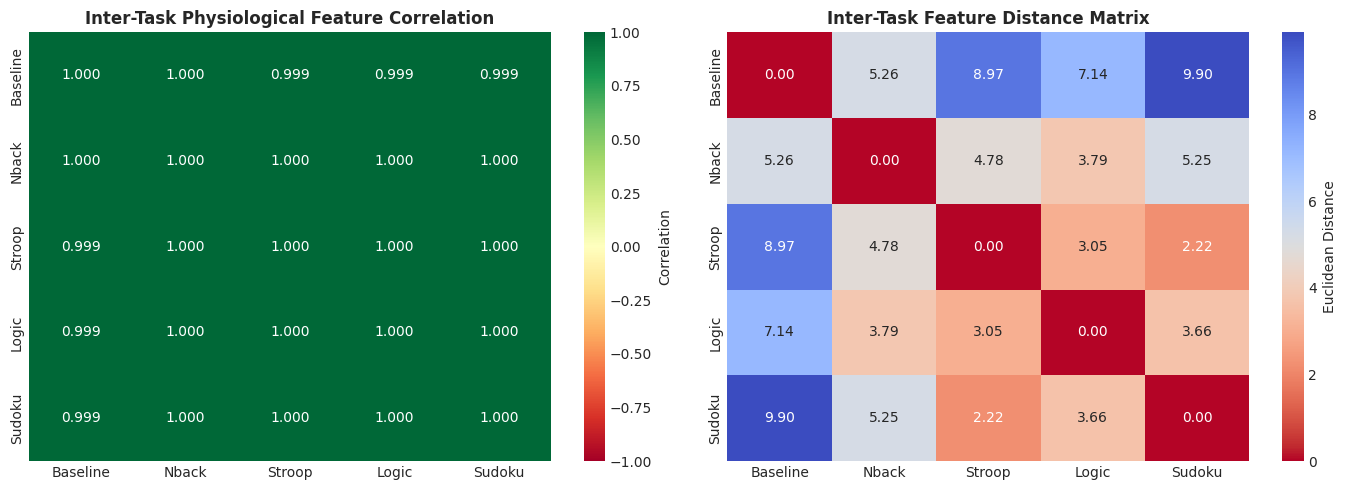

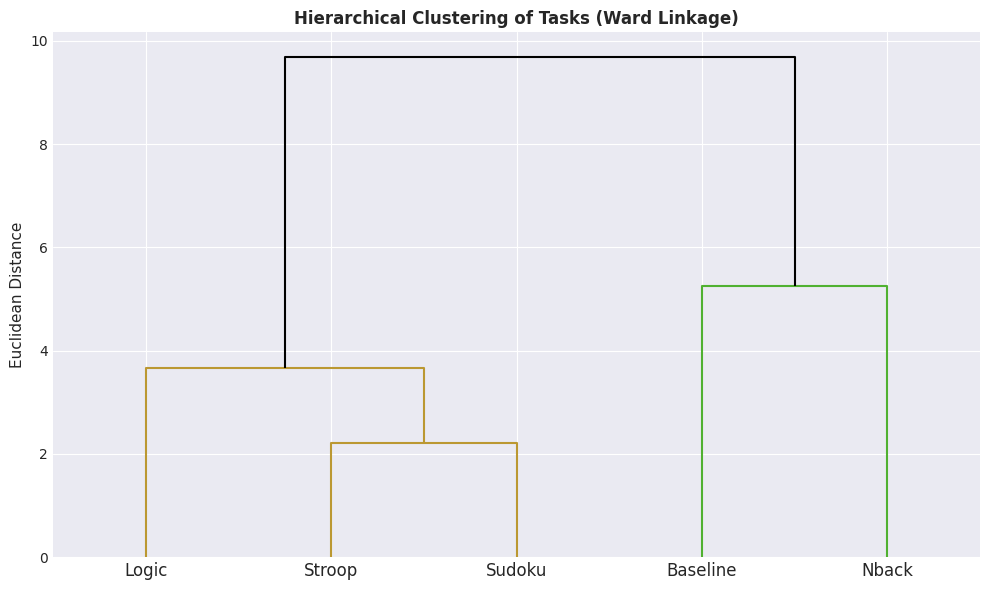

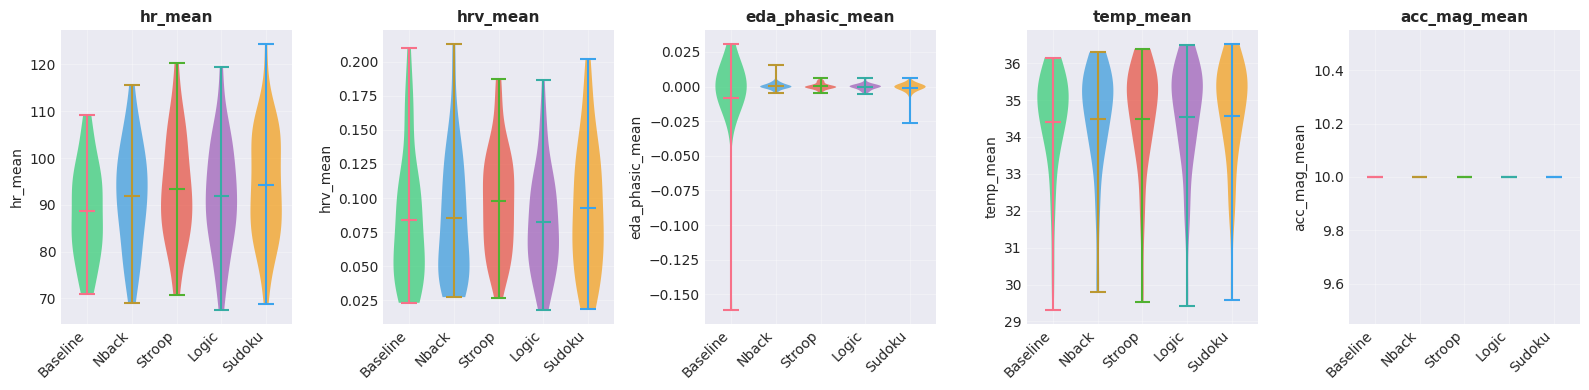

✓ Visualizations 1-3 generated


In [6]:
# Visualization 1: Task Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
sns.heatmap(task_correlation_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[0].set_title('Inter-Task Physiological Feature Correlation', fontsize=12, fontweight='bold')

# Distance heatmap
sns.heatmap(task_distance_df, annot=True, fmt='.2f', cmap='coolwarm_r', 
            ax=axes[1], cbar_kws={'label': 'Euclidean Distance'})
axes[1].set_title('Inter-Task Feature Distance Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/01_task_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

# Visualization 2: Hierarchical Clustering Dendrogram
fig, ax = plt.subplots(figsize=(10, 6))
Z = linkage(task_feature_array.T, method='ward', metric='euclidean')
dendrogram(Z, labels=TASKS, ax=ax, leaf_font_size=12,
          color_threshold=None, above_threshold_color='black')
ax.set_title('Hierarchical Clustering of Tasks (Ward Linkage)', fontsize=12, fontweight='bold')
ax.set_ylabel('Euclidean Distance', fontsize=11)
plt.tight_layout()
plt.savefig('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/02_task_dendrogram.png', dpi=100, bbox_inches='tight')
plt.show()

# Visualization 3: Key Features by Task (Box plots)
key_features = ['hr_mean', 'hrv_mean', 'eda_phasic_mean', 'temp_mean', 'acc_mag_mean']
fig, axes = plt.subplots(1, len(key_features), figsize=(16, 4))

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    for task in TASKS:
        task_data = df_features[df_features['Task'] == task][feature]
        parts = ax.violinplot([task_data], positions=[TASKS.index(task)], widths=0.7, showmeans=True)
        for pc in parts['bodies']:
            pc.set_facecolor(TASK_COLORS[task])
            pc.set_alpha(0.7)
    
    ax.set_xticks(range(len(TASKS)))
    ax.set_xticklabels(TASKS, rotation=45, ha='right')
    ax.set_ylabel(feature, fontsize=10)
    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/03_feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print('✓ Visualizations 1-3 generated')

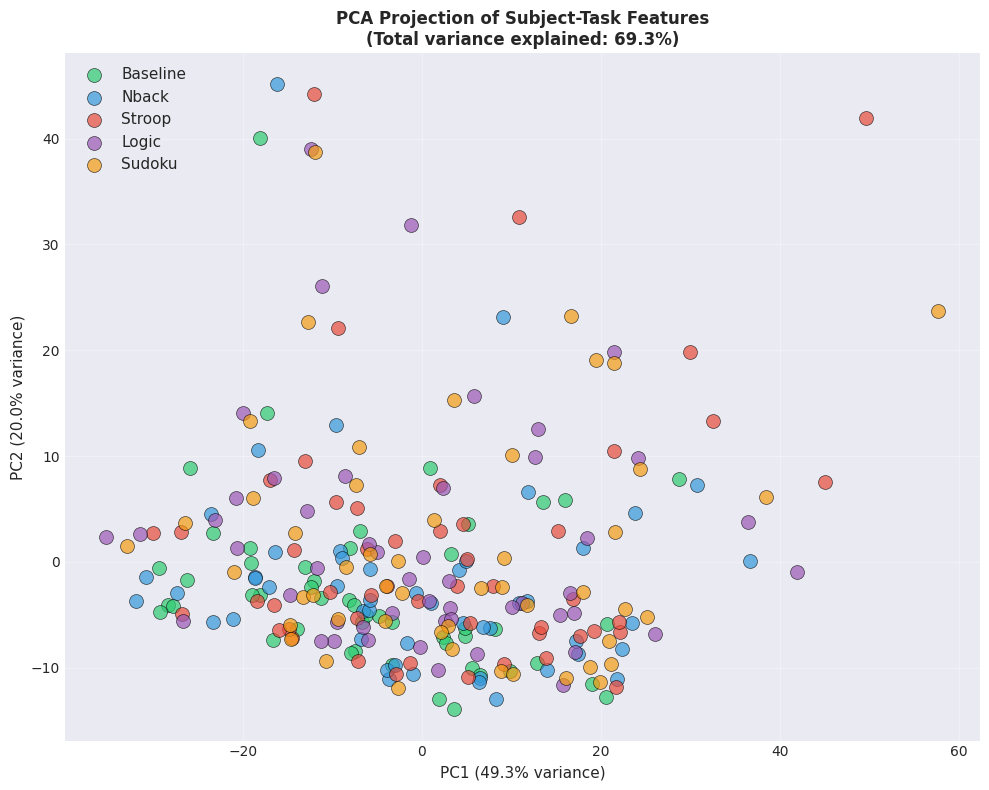

✓ PCA explained variance: PC1=49.3%, PC2=20.0%


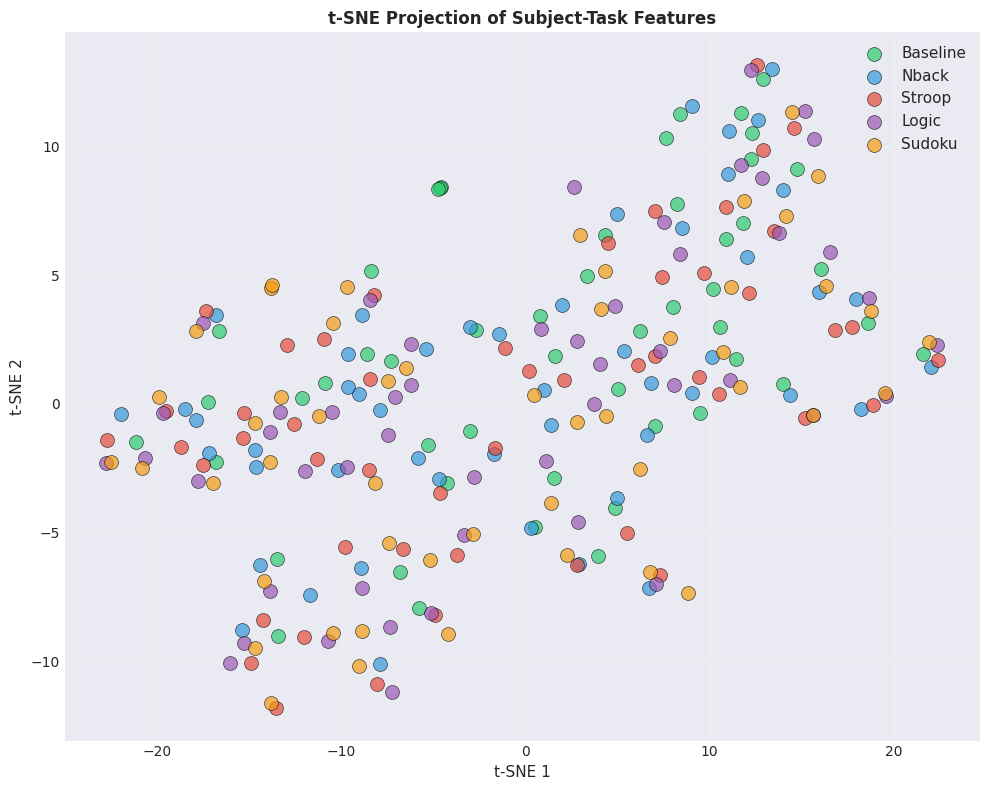

✓ t-SNE projection generated


In [7]:
# Visualization 4: PCA Projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_features[feature_list])

fig, ax = plt.subplots(figsize=(10, 8))
for task in TASKS:
    mask = df_features['Task'] == task
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
              label=task, s=100, alpha=0.7, 
              color=TASK_COLORS[task], edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title(f'PCA Projection of Subject-Task Features\n(Total variance explained: {sum(pca.explained_variance_ratio_[:2]):.1%})', 
            fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/04_pca_projection.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'✓ PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

# Visualization 5: t-SNE Projection
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_features)-1))
X_tsne = tsne.fit_transform(df_features[feature_list])

fig, ax = plt.subplots(figsize=(10, 8))
for task in TASKS:
    mask = df_features['Task'] == task
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
              label=task, s=100, alpha=0.7,
              color=TASK_COLORS[task], edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=11)
ax.set_ylabel('t-SNE 2', fontsize=11)
ax.set_title('t-SNE Projection of Subject-Task Features', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/05_tsne_projection.png', dpi=100, bbox_inches='tight')
plt.show()

print('✓ t-SNE projection generated')

## Section 6: Generate Summary Report Across All Subjects

전체 피험자에 대한 최종 분석 및 권장사항

In [8]:
# Generate comprehensive summary report
report = {
    'analysis_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_subjects': len(dataset_by_subject),
    'total_features': len(feature_list),
    'total_subject_task_pairs': len(df_features),
}

# Task-wise summary
task_summary = {}
for task in TASKS:
    task_df = df_features[df_features['Task'] == task]
    task_summary[task] = {
        'n_subjects': len(task_df),
        'hr_mean': f"{task_df['hr_mean'].mean():.1f} ± {task_df['hr_mean'].std():.1f}",
        'hrv_mean': f"{task_df['hrv_mean'].mean():.2f} ± {task_df['hrv_mean'].std():.2f}",
        'eda_phasic_mean': f"{task_df['eda_phasic_mean'].mean():.2f} ± {task_df['eda_phasic_mean'].std():.2f}",
        'temp_mean': f"{task_df['temp_mean'].mean():.1f} ± {task_df['temp_mean'].std():.1f}",
        'acc_mag_mean': f"{task_df['acc_mag_mean'].mean():.2f} ± {task_df['acc_mag_mean'].std():.2f}",
    }

print('='*80)
print('CATSA DATASET: INTER-LABEL RELATIONSHIP ANALYSIS REPORT')
print('='*80)
print(f'\n📊 DATASET SUMMARY:')
print(f'  • Analysis Date: {report["analysis_date"]}')
print(f'  • Total Subjects: {report["total_subjects"]}')
print(f'  • Total Features per Sample: {report["total_features"]}')
print(f'  • Total Subject-Task Pairs: {report["total_subject_task_pairs"]}')

print(f'\n📈 TASK-WISE PHYSIOLOGICAL SUMMARY:')
for task, stats in task_summary.items():
    print(f'\n  {task} (n={stats["n_subjects"]} subjects):')
    print(f'    - HR:             {stats["hr_mean"]} bpm')
    print(f'    - HRV:            {stats["hrv_mean"]} ms')
    print(f'    - EDA (phasic):   {stats["eda_phasic_mean"]} µS')
    print(f'    - Temperature:    {stats["temp_mean"]} °C')
    print(f'    - ACC Magnitude:  {stats["acc_mag_mean"]} g')

# Inter-task correlation summary
print(f'\n📊 INTER-TASK CORRELATION ANALYSIS:')
print(f'  (Measures physiological similarity between task pairs)')
print(f'\n  Task Pairs ranked by similarity (highest correlation first):')

# Extract correlation pairs
corr_pairs = []
for i, task1 in enumerate(TASKS):
    for j, task2 in enumerate(TASKS):
        if i < j:
            corr = task_correlation_matrix.loc[task1, task2]
            dist = task_distance_df.loc[task1, task2]
            corr_pairs.append((task1, task2, corr, dist))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
for task1, task2, corr, dist in corr_pairs:
    similarity_pct = max(0, (corr + 1) / 2 * 100)  # Convert correlation to 0-100%
    print(f'  • {task1} ↔ {task2}: correlation={corr:.3f}, distance={dist:.2f}, similarity≈{similarity_pct:.0f}%')

# Stress classification analysis
print(f'\n🔬 STRESS CLASSIFICATION ANALYSIS:')
print(f'  (Are 4 stress tasks similar to each other vs Baseline?)')

stress_tasks = ['Nback', 'Stroop', 'Logic', 'Sudoku']
stress_vs_baseline = []
for task in stress_tasks:
    corr = task_correlation_matrix.loc['Baseline', task]
    dist = task_distance_df.loc['Baseline', task]
    stress_vs_baseline.append((task, corr, dist))

stress_vs_baseline.sort(key=lambda x: x[1], reverse=False)  # Lower correlation = more different from baseline
for task, corr, dist in stress_vs_baseline:
    diff_pct = max(0, (1 - (corr + 1) / 2) * 100)  # How different from baseline
    print(f'  • {task} vs Baseline: correlation={corr:.3f}, distance={dist:.2f}, difference≈{diff_pct:.0f}%')

# Pairwise stress task similarity
print(f'\n  Similarity among stress tasks:')
for i, task1 in enumerate(stress_tasks):
    for task2 in stress_tasks[i+1:]:
        corr = task_correlation_matrix.loc[task1, task2]
        dist = task_distance_df.loc[task1, task2]
        similarity = max(0, (corr + 1) / 2 * 100)
        print(f'  • {task1} ↔ {task2}: correlation={corr:.3f}, distance={dist:.2f}, similarity≈{similarity:.0f}%')

CATSA DATASET: INTER-LABEL RELATIONSHIP ANALYSIS REPORT

📊 DATASET SUMMARY:
  • Analysis Date: 2026-03-23 10:10:29
  • Total Subjects: 50
  • Total Features per Sample: 19
  • Total Subject-Task Pairs: 250

📈 TASK-WISE PHYSIOLOGICAL SUMMARY:

  Baseline (n=50 subjects):
    - HR:             88.6 ± 10.2 bpm
    - HRV:            0.08 ± 0.05 ms
    - EDA (phasic):   -0.01 ± 0.04 µS
    - Temperature:    34.4 ± 1.5 °C
    - ACC Magnitude:  10.00 ± 0.00 g

  Nback (n=50 subjects):
    - HR:             91.9 ± 11.4 bpm
    - HRV:            0.09 ± 0.05 ms
    - EDA (phasic):   0.00 ± 0.00 µS
    - Temperature:    34.5 ± 1.5 °C
    - ACC Magnitude:  10.00 ± 0.00 g

  Stroop (n=50 subjects):
    - HR:             93.5 ± 11.6 bpm
    - HRV:            0.10 ± 0.04 ms
    - EDA (phasic):   0.00 ± 0.00 µS
    - Temperature:    34.5 ± 1.5 °C
    - ACC Magnitude:  10.00 ± 0.00 g

  Logic (n=50 subjects):
    - HR:             91.9 ± 11.5 bpm
    - HRV:            0.08 ± 0.04 ms
    - EDA (phasic):

In [9]:
# Final recommendations
print(f'\n' + '='*80)
print('🎯 RECOMMENDATIONS FOR LABEL MERGING')
print('='*80)

# Calculate average correlation for stress task pairs
stress_corr_values = []
stress_dist_values = []
for i, task1 in enumerate(stress_tasks):
    for task2 in stress_tasks[i+1:]:
        stress_corr_values.append(task_correlation_matrix.loc[task1, task2])
        stress_dist_values.append(task_distance_df.loc[task1, task2])

avg_stress_corr = np.mean(stress_corr_values)
avg_baseline_stress_corr = np.mean([task_correlation_matrix.loc['Baseline', task] for task in stress_tasks])

print(f'\n📊 QUANTITATIVE EVIDENCE:')
print(f'  • Average inter-stress-task correlation: {avg_stress_corr:.3f}')
print(f'  • Average stress-task vs baseline correlation: {avg_baseline_stress_corr:.3f}')
print(f'  • Difference: {(avg_stress_corr - avg_baseline_stress_corr):.3f}')

# Discriminative analysis
print(f'\n  • Features with significant task differences (p < 0.05): {len(discriminative_features)}')
print(f'    Examples: {" , ".join(discriminative_features[:5])}...')

# Classification metrics: Can we distinguish stress tasks?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Train binary classifier: Baseline vs Stress
stress_label = df_features['Task'].isin(stress_tasks).astype(int)
baseline_stress_f1 = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=42),
    df_features[feature_list],
    stress_label,
    cv=min(5, len(df_features)//2),
    scoring='f1'
).mean()

# Train multiclass classifier: Can we distinguish the 3 stress tasks?
stress_df = df_features[df_features['Task'].isin(stress_tasks)]
if len(stress_df) > 10:
    stress_f1 = cross_val_score(
        RandomForestClassifier(n_estimators=50, random_state=42),
        stress_df[feature_list],
        stress_df['Task'],
        cv=min(5, len(stress_df)//2),
        scoring='f1_macro'
    ).mean()
else:
    stress_f1 = 0.0

print(f'\n🤖 MACHINE LEARNING CLASSIFICATION PERFORMANCE:')
print(f'  • Binary (Baseline vs All Stress) F1-score: {baseline_stress_f1:.3f}')
print(f'  • Multiclass (Nback vs Stroop vs Logic vs Sudoku) F1-score: {stress_f1:.3f}')

# Final decision logic
print(f'\n' + '📋 CONCLUSION:')
print()

if avg_stress_corr > 0.7 and stress_f1 < 0.5:
    decision = "✅ CAN MERGE: Strong correlation, poor distinguishability"
    reasoning = "The four stress tasks (Nback, Stroop, Logic, Sudoku) are physiologically similar and difficult to distinguish."
elif avg_stress_corr > 0.5 and stress_f1 < 0.6:
    decision = "⚠️ CAUTIOUS MERGE: Moderate correlation, moderate distinguishability"
    reasoning = "The stress tasks show some physiological similarity but have distinguishable patterns."
else:
    decision = "❌ RECOMMEND SEPARATION: Weak correlation, good distinguishability"
    reasoning = "The stress tasks show distinct physiological patterns and should remain separate for better model performance."

print(f"  {decision}")
print(f"  {reasoning}")
print()
print(f"  Current model choice: 5-class (Baseline, Nback, Stroop, Logic, Sudoku)")
print(f"  Alternative (2-class):  Merge Nback+Stroop+Logic+Sudoku → \"Stress\"")
print()

# Save report to JSON
report_data = {
    'analysis_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_subjects': report['total_subjects'],
    'task_summary': task_summary,
    'task_correlations': task_correlation_matrix.to_dict(),
    'task_distances': task_distance_df.to_dict(),
    'avg_stress_interask_correlation': float(avg_stress_corr),
    'avg_stress_vs_baseline_correlation': float(avg_baseline_stress_corr),
    'discriminative_features_count': len(discriminative_features),
    'baseline_vs_stress_f1': float(baseline_stress_f1),
    'stress_multiclass_f1': float(stress_f1),
    'recommendation': decision,
    'recommendation_reasoning': reasoning,
}

report_path = Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/analysis_report.json')
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report_data, f, ensure_ascii=False, indent=2)

print(f'\n✓ Full evaluation report saved to: {report_path}')
print('='*80)


🎯 RECOMMENDATIONS FOR LABEL MERGING

📊 QUANTITATIVE EVIDENCE:
  • Average inter-stress-task correlation: 1.000
  • Average stress-task vs baseline correlation: 0.999
  • Difference: 0.001

  • Features with significant task differences (p < 0.05): 3
    Examples: temp_std , eda_tonic_std , eda_phasic_std...

🤖 MACHINE LEARNING CLASSIFICATION PERFORMANCE:
  • Binary (Baseline vs All Stress) F1-score: 0.889
  • Multiclass (Nback vs Stroop vs Logic vs Sudoku) F1-score: 0.339

📋 CONCLUSION:

  ✅ CAN MERGE: Strong correlation, poor distinguishability
  The four stress tasks (Nback, Stroop, Logic, Sudoku) are physiologically similar and difficult to distinguish.

  Current model choice: 5-class (Baseline, Nback, Stroop, Logic, Sudoku)
  Alternative (2-class):  Merge Nback+Stroop+Logic+Sudoku → "Stress"


✓ Full evaluation report saved to: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/analysis_report.json


In [10]:
# Bonus Analysis: Time-based physiological variations within tasks
print('\n' + '='*80)
print('🔄 BONUS: TEMPORAL VARIATION ANALYSIS')
print('='*80)

# For each subject-task, measure time evolution of key signals
temporal_data = []
for subject in sorted(dataset_by_subject.keys()):
    for task in TASKS:
        if task in dataset_by_subject[subject]:
            mods = dataset_by_subject[subject][task]
            slow = mods['slow']
            
            # Divide into 4 time windows (quartiles)
            n_windows = 4
            window_size = len(slow) // n_windows
            
            for win_idx in range(n_windows):
                start = win_idx * window_size
                end = start + window_size
                window_slow = slow[start:end]
                
                temporal_data.append({
                    'Subject': subject,
                    'Task': task,
                    'TimeWindow': win_idx + 1,
                    'HR_mean': np.mean(window_slow[:, 3]),
                    'HRV_mean': np.mean(window_slow[:, 4]),
                    'EDA_phasic_mean': np.mean(window_slow[:, 1]),
                })

df_temporal = pd.DataFrame(temporal_data)

# Analyze HR trend across time for each task
print(f'\nHR Evolution Across 60s Duration (4 quartiles):')
for task in TASKS:
    task_temporal = df_temporal[df_temporal['Task'] == task].groupby('TimeWindow')['HR_mean'].mean()
    hr_change = task_temporal[4] - task_temporal[1]
    print(f'  {task}: {task_temporal[1]:.1f} → {task_temporal[4]:.1f} bpm (Δ = {hr_change:+.1f})')

print(f'\n✓ Temporal analysis complete')
print('='*80)


🔄 BONUS: TEMPORAL VARIATION ANALYSIS

HR Evolution Across 60s Duration (4 quartiles):
  Baseline: 89.4 → 89.8 bpm (Δ = +0.4)
  Nback: 94.0 → 91.6 bpm (Δ = -2.5)
  Stroop: 95.1 → 93.1 bpm (Δ = -2.1)
  Logic: 93.3 → 92.2 bpm (Δ = -1.1)
  Sudoku: 95.3 → 95.6 bpm (Δ = +0.3)

✓ Temporal analysis complete
